# NBM: Neural Basis Model

NBM learns shared neural basis functions for n-ary concept tuples, combines each tuple's basis responses independently, and applies a final linear output layer.


## Model in one view


For tuple $S$ of order $o$ and $K$ learned bases,

$$
b_o(x_S)\in\mathbb R^K,\qquad
h_S(x_S)=a_S^\top b_o(x_S)+c_S,
\qquad
\eta(x)=\beta_0+\sum_S v_Sh_S(x_S).
$$

The default grouped $1\times1$ convolution implements all $a_S$ independently.



NBM separates representation learning from concept-specific combination.
Shared neural basis functions are evaluated for every concept tuple, after
which independent linear weights assemble each tuple's contribution. Sharing
reduces the parameter cost relative to a separate deep network per feature,
while the final sum retains a named additive decomposition.

Unary NBM is a learned-basis additive model. Higher `nary` orders create
explicit interactions, and sparse execution can omit inactive tuples. The
Conv1D and einsum featurizers are two algebraically equivalent implementations
of the same grouped combination.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#EF4444"]

rng = np.random.default_rng(7)
n = 180
X = pd.DataFrame({
    "x1": rng.uniform(-1.0, 1.0, n),
    "x2": rng.normal(size=n),
    "group": rng.choice(["a", "b", "c"], size=n),
})
y = (
    np.sin(np.pi * X["x1"])
    + 0.35 * X["x2"] ** 2
    + 0.30 * (X["group"] == "b")
    + rng.normal(0.0, 0.12, n)
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7
)


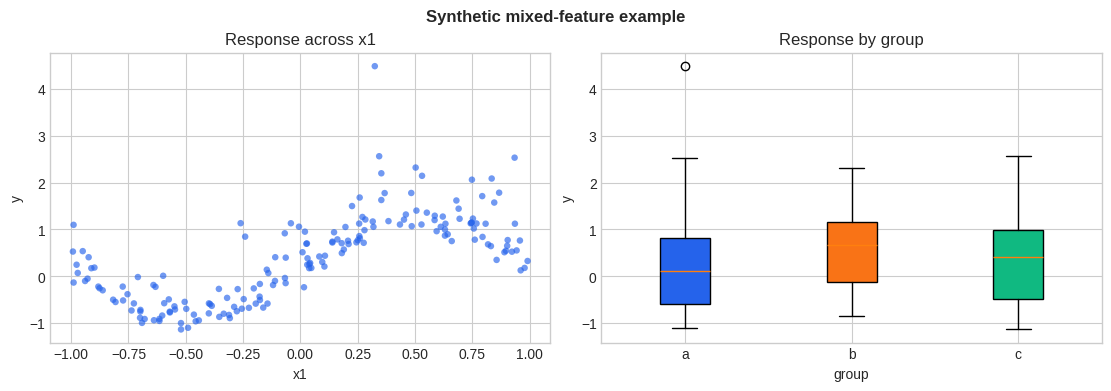

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
axes[0].scatter(X["x1"], y, s=22, alpha=0.65, color=COLORS[0], edgecolor="none")
axes[0].set(title="Response across x1", xlabel="x1", ylabel="y")

group_order = ["a", "b", "c"]
group_values = [y[X["group"].to_numpy() == level] for level in group_order]
boxes = axes[1].boxplot(group_values, tick_labels=group_order, patch_artist=True)
for patch, color in zip(boxes["boxes"], COLORS, strict=False):
    patch.set_facecolor(color)
axes[1].set(title="Response by group", xlabel="group", ylabel="y")
fig.suptitle("Synthetic mixed-feature example", fontweight="bold")
plt.show()
plt.close(fig)


## Fit the model


In [3]:
from nampy.models import NBMClassifier, NBMLSS, NBMRegressor


model = NBMRegressor(
    nary=[1, 2],
    num_bases=16,
    layer_sizes=[32, 16],
    featurizer="conv1d",
    sparse=False,
    batch_norm=True,
)
model.get_params(deep=False)


{'activation': torch.nn.modules.activation.ReLU,
 'bases_dropout': 0.0,
 'batch_norm': True,
 'dropout': 0.0,
 'feature_dropout': 0.0,
 'featurizer': 'conv1d',
 'interaction_degree': None,
 'intercept': True,
 'layer_norm': False,
 'layer_sizes': [32, 16],
 'lr': 0.0001,
 'lr_factor': 0.1,
 'lr_patience': 10,
 'nary': [1, 2],
 'nary_ignore_input': 0.0,
 'norm': None,
 'num_bases': 16,
 'num_subnets': 1,
 'order': 1,
 'output_penalty': 0.0,
 'skip_connections': False,
 'sparse': False,
 'use_glu': False,
 'weight_decay': 1e-06,
 'feature_preprocessing': None,
 'n_bins': 64,
 'numerical_preprocessing': 'none',
 'categorical_preprocessing': 'one-hot',
 'use_decision_tree_bins': False,
 'binning_strategy': 'uniform',
 'task': 'regression',
 'cat_cutoff': 0.03,
 'treat_all_integers_as_numerical': False,
 'degree': 3,
 'scaling_strategy': 'minmax',
 'n_knots': 64,
 'use_decision_tree_knots': True,
 'knots_strategy': 'uniform',
 'spline_implementation': 'sklearn',
 'min_unique_vals': 5}

In [4]:
model.fit(
    X_train,
    y_train,
    max_epochs=3,
    batch_size=64,
    random_state=7,
    logger=False,
    enable_progress_bar=False,
    enable_model_summary=False,
)
predictions = model.predict(X_test)
r2 = model.score(X_test, y_test)
metrics = model.evaluate(X_test, y_test)
components = model.predict_components(X_test)
explanation = model.explain_terms(X_test, max_bins=24, center=True)
importance = model.term_importance(X_test, center=True)
interaction_importance = model.interaction_importance(X_test, center=True)
display({"R2": r2, **metrics})
display(importance)
display(explanation.head(12))


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/opt/hostedtoolcache/Python/3.11.16/x64/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
`Trainer.fit` stopped: `max_epochs=3` reached.


{'R2': -0.5867065273304184, 'Mean Squared Error': 1.1073754391920596}

,term,term_type,output,importance
0,x1:group[1],interaction,0,0.006643
1,x2:group[0],interaction,0,0.004440
2,x1,main,0,0.003978
3,group[0]:group[2],interaction,0,0.002860
4,group[1],main,0,0.002731
5,group[1]:group[2],interaction,0,0.002709
6,x2:group[1],interaction,0,0.000779
7,group[2],main,0,0.000681
8,x1:group[2],interaction,0,0.000660
9,x2:group[2],interaction,0,0.000538


,term,term_type,output,value,value_2,contribution,count,importance
0,x1,main,0,-0.965,NaN,0.006262,2,0.003978
1,x1,main,0,-0.8895,NaN,0.006112,2,0.003978
2,x1,main,0,-0.7905,NaN,0.005746,2,0.003978
3,x1,main,0,-0.6915,NaN,0.005677,2,0.003978
4,x1,main,0,-0.58,NaN,0.005586,2,0.003978
5,x1,main,0,-0.4875,NaN,0.005556,2,0.003978
6,x1,main,0,-0.35,NaN,0.004527,1,0.003978
7,x1,main,0,-0.209,NaN,0.003940,2,0.003978
8,x1,main,0,-0.12505,NaN,0.002370,2,0.003978
9,x1,main,0,-0.05205,NaN,0.001241,2,0.003978


## Evaluate and explain


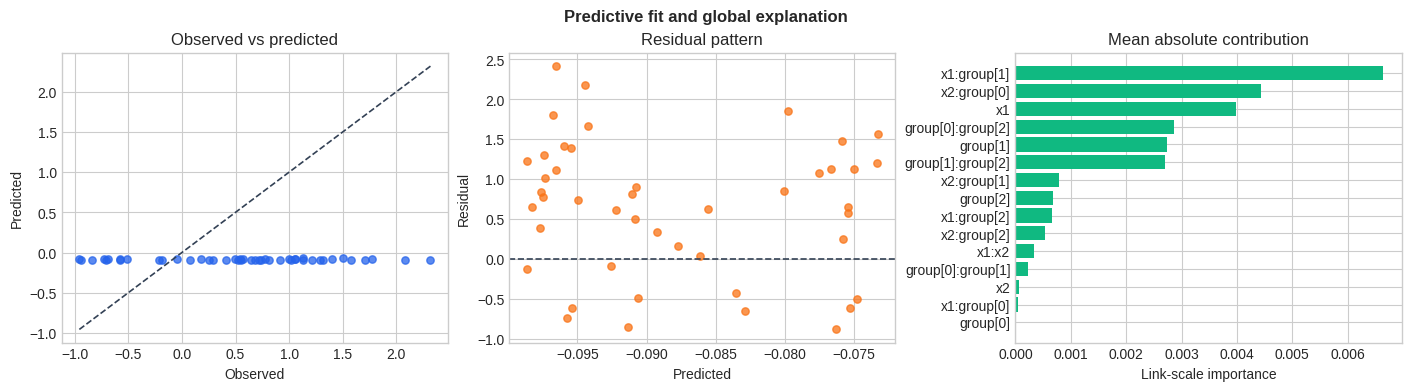

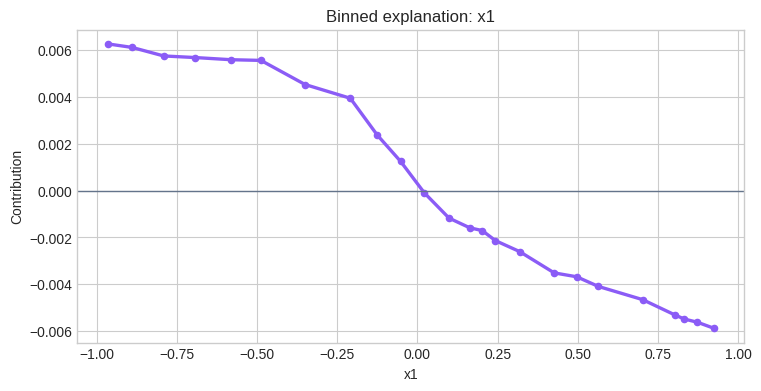

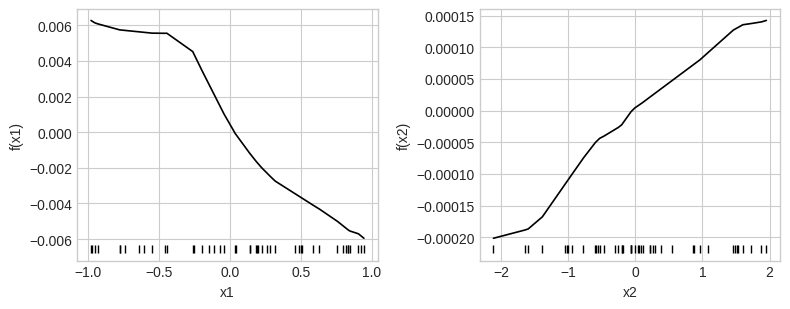

In [5]:
observed = np.asarray(y_test).reshape(-1)
fitted = np.asarray(predictions).reshape(-1)
residual = observed - fitted

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].scatter(observed, fitted, s=28, alpha=0.75, color=COLORS[0])
lo = min(observed.min(), fitted.min())
hi = max(observed.max(), fitted.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#334155", linewidth=1.2)
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(fitted, residual, s=28, alpha=0.75, color=COLORS[1])
axes[1].axhline(0.0, color="#334155", linestyle="--", linewidth=1.2)
axes[1].set(title="Residual pattern", xlabel="Predicted", ylabel="Residual")

importance_plot = (
    importance.groupby("term", as_index=False)["importance"]
    .mean()
    .sort_values("importance")
)
axes[2].barh(importance_plot["term"], importance_plot["importance"], color=COLORS[2])
axes[2].set(title="Mean absolute contribution", xlabel="Link-scale importance")
fig.suptitle("Predictive fit and global explanation", fontweight="bold")
plt.show()
plt.close(fig)

main_effects = explanation.loc[
    (explanation["term_type"] == "main") & (explanation["output"] == 0)
].copy()
main_effects["numeric_value"] = pd.to_numeric(main_effects["value"], errors="coerce")
main_effects = main_effects.dropna(subset=["numeric_value"])
if not main_effects.empty:
    numeric_terms = set(main_effects["term"])
    top_term = next(
        term
        for term in importance_plot.sort_values("importance", ascending=False)["term"]
        if term in numeric_terms
    )
    curve = main_effects.loc[main_effects["term"] == top_term].sort_values("numeric_value")
    if not curve.empty:
        fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
        ax.plot(curve["numeric_value"], curve["contribution"], color=COLORS[3], linewidth=2.4)
        ax.scatter(curve["numeric_value"], curve["contribution"], s=20, color=COLORS[3])
        ax.axhline(0.0, color="#64748B", linewidth=1)
        ax.set(title=f"Binned explanation: {top_term}", xlabel=top_term, ylabel="Contribution")
        plt.show()
        plt.close(fig)

term_figures = model.plot_terms(X_test, center=True, rug=True, pages=1)
interaction_terms = interaction_importance["term"].astype(str).tolist()
interactions_are_raw_columns = all(
    all(
        part in X_test.columns
        and pd.api.types.is_numeric_dtype(X_test[part])
        for part in term.split(":")
    )
    for term in interaction_terms
)
if interaction_terms and interactions_are_raw_columns:
    model.plot_interactions(X_test)


## Model-specific controls

Use `nary`, `order`, or `interaction_degree` to define tuples. `featurizer='conv1d'` matches upstream; `einsum` is equivalent. Sparse execution is a configuration option, not a separate class.


In [6]:
einsum_model = NBMRegressor(
    nary=[1, 2], num_bases=16, featurizer="einsum", sparse=False
)
sparse_model = NBMRegressor(
    nary=[1], num_bases=16, sparse=True, nary_ignore_input=0.0
)
display({key: model.get_params(deep=False)[key] for key in ("nary", "featurizer", "sparse")})
display(model.predict_components(X_test).terms.keys())


{'nary': [1, 2], 'featurizer': 'conv1d', 'sparse': False}

dict_keys(['x1', 'x2', 'group[0]', 'group[1]', 'group[2]', 'x1:x2', 'x1:group[0]', 'x1:group[1]', 'x1:group[2]', 'x2:group[0]', 'x2:group[1]', 'x2:group[2]', 'group[0]:group[1]', 'group[0]:group[2]', 'group[1]:group[2]'])

## Supported task variants

NBM is available as `NBMRegressor`, `NBMClassifier`, and `NBMLSS`. PreTab emits one scalar encoded column per NBM concept.


In [7]:
task_variants = {"regression": NBMRegressor(), "classification": NBMClassifier(), "distributional": NBMLSS()}


## References

- [Radenovic et al. (2022), Neural Basis Models](https://proceedings.neurips.cc/paper_files/paper/2022/hash/37da88965c016dca016514df0e420c72-Abstract-Conference.html).
